In [1]:
from julia.api import Julia
from julia import Main

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from multiprocessing import Pool
from concurrent.futures import ProcessPoolExecutor
import concurrent.futures

import scipy.special as sp
import os

import pathlib
from pathlib import Path
import json

Which Fit?

In [2]:
fit_name = "MSHT20N3LO-CS"
if_grid = True
data_uncertainty_only = False

Initialize Parameters

In [3]:
Main.eval('using Distributed')
Main.eval('addprocs(8)') 

TMD_fitting_root = "../"
def include(name):
    path = os.path.join(TMD_fitting_root, name)
    Main.eval(f'@everywhere include(raw"{path}")')

include(f"Cards/{fit_name}.jl")

def Push_Params(params):

    lines = []
    for name, val in zip(Main.param_names, params):
        v = float(val)
        lines.append(f"NP_{name} = Float32({v})")
    assigns = "\n        ".join(lines)

    Main.eval(f"""
        using Distributed
        @everywhere begin
            {assigns}
        end
    """)

initial_params = Main.initial_params
Push_Params(initial_params)

Read Files

In [4]:
Main.if_grid = bool(if_grid)
Main.fit_name = str(fit_name)
Main.if_generate_table = False

Main.eval("""
using Distributed
@everywhere begin
    # declare globals in this process's Main
    global if_grid, fit_name, if_generate_table

    # copy values from pid 1 explicitly
    if_grid           = remotecall_fetch(() -> Main.if_grid, 1)
    fit_name          = remotecall_fetch(() -> Main.fit_name, 1)
    if_generate_table = remotecall_fetch(() -> false, 1)
end
""")

# Grids
if if_grid == True:
    include(f"Tables/runtime_NP_grid_{Main.flavor_scheme}.jl")
# PDF
include("Collinear_PDF/pdf.jl")
# Core
include("Core/constants.jl")
# Numerical
include("Numerical/MultiGKTable.jl")
include("Numerical/FastGK.jl")
# TMDs
include(f"TMDs/NP Parameterizations/{Main.NP_name}")
# DY
include(f"DY/DY_table.jl")

# Data
file_root = f"../Data/{Main.data_name}/Cutted/DY"
matrix_root = f"../Data/{Main.data_name}/Covariance_Matrices/DY"
table_root = f"../Tables/{Main.table_name}/DY"
total_root = f"../Data/DY_total_xsec/{Main.total_xsec_name}"
error_sets_root = f"../Data/PDF_Matrices/{Main.error_sets_name}/DY"

if Main.total_xsec_name == "approximate":
    approximate_total_xsec = True
else:
    approximate_total_xsec = False

LHAPDF 6.5.5 loading /home/maxzhang/UCLA_QCD_fitter/installation/share/LHAPDF/MSHT20an3lo_as118/MSHT20an3lo_as118_0000.dat
MSHT20an3lo_as118 PDF set, member #0, version 2; LHAPDF ID = 29100
LHAPDF 6.5.5 loading /home/maxzhang/UCLA_QCD_fitter/installation/share/LHAPDF/MSHT20an3lo_as118/MSHT20an3lo_as118_0104.dat
MSHT20an3lo_as118 PDF set, member #104, version 2; LHAPDF ID = 29204
      From worker 6:	LHAPDF 6.5.5 loading /home/maxzhang/UCLA_QCD_fitter/installation/share/LHAPDF/MSHT20an3lo_as118/MSHT20an3lo_as118_0000.dat
      From worker 6:	MSHT20an3lo_as118 PDF set, member #0, version 2; LHAPDF ID = 29100
      From worker 6:	LHAPDF 6.5.5 loading /home/maxzhang/UCLA_QCD_fitter/installation/share/LHAPDF/MSHT20an3lo_as118/MSHT20an3lo_as118_0104.dat
      From worker 6:	MSHT20an3lo_as118 PDF set, member #104, version 2; LHAPDF ID = 29204
      From worker 9:	LHAPDF 6.5.5 loading /home/maxzhang/UCLA_QCD_fitter/installation/share/LHAPDF/MSHT20an3lo_as118/MSHT20an3lo_as118_0000.dat
      Fr

In [5]:
def to_float64(df):
    num_cols = df.select_dtypes(include=["number"]).columns
    df[num_cols] = df[num_cols].astype("float64")
    return df

df_predictions = dict([])

By file or by experiment?

In [6]:
data_selections = "by_experiment"  # "by_file" or "by_experiment"

In [7]:
experiments =[
    'ATLAS_7',
    'ATLAS_8', 
    'ATLAS_13', 
    'CDF_I',
    'CDF_II',
    'CMS_7',
    'CMS_8',
    'CMS_13',    
    'D0_I',
    'D0_II',
    'D0_II_mu',
    'E288',
    'E605',
    'E772',
    'LHCb_7',
    'LHCb_8',
    'LHCb_13',    
    #'PHENIX',
    'STAR'
]

#["E288","E605","E772","ATLAS", "CMS", "D0", "CDF", "LHCb", "PHENIX", "STAR"]

if data_selections == "by_file":
    file_names = [

    #----------------------------------------------------------------------------
    # ATLAS
    #----------------------------------------------------------------------------

    #"ATLAS/ATLAS_7TeV_y_0_1.csv",
    #"ATLAS/ATLAS_7TeV_y_1_2.csv",
    #"ATLAS/ATLAS_7TeV_y_2_2.4.csv",

    #"ATLAS/ATLAS_8TeV_Q_44_66.csv",
    #"ATLAS/ATLAS_8TeV_Q_116_150.csv",

    #"ATLAS/ATLAS_8TeV_y_0_0.4.csv"
    #"ATLAS/ATLAS_8TeV_y_0.4_0.8.csv"
    #"ATLAS/ATLAS_8TeV_y_0.8_1.2.csv"
    #"ATLAS/ATLAS_8TeV_y_1.2_1.6.csv",
    #"ATLAS/ATLAS_8TeV_y_1.6_2.csv",
    #"ATLAS/ATLAS_8TeV_y_2_2.4.csv",

    #----------------------------------------------------------------------------
    # CDF
    #----------------------------------------------------------------------------

    #"CDF/CDF_RunI.csv",
    #"CDF/CDF_RunII.csv",

    #----------------------------------------------------------------------------
    # CMS
    #----------------------------------------------------------------------------

    #"CMS/CMS_7TeV.csv",
    #"CMS/CMS_8TeV.csv",
    
    #"CMS/CMS_13TeV_y_0_0.4.csv",
    #"CMS/CMS_13TeV_y_0.4_0.8.csv",
    #"CMS/CMS_13TeV_y_0.8_1.2.csv",
    #"CMS/CMS_13TeV_y_1.2_1.6.csv",
    #"CMS/CMS_13TeV_y_1.6_2.4.csv",

    #----------------------------------------------------------------------------
    # D0
    #----------------------------------------------------------------------------

    #"D0/D0_RunI.csv",
    #"D0/D0_RunII.csv",
    #"D0/D0_RunIImu.csv",

    #----------------------------------------------------------------------------
    # LHCb
    #----------------------------------------------------------------------------

    #"LHCb/LHCb_7TeV.csv",
    #"LHCb/LHCb_8TeV.csv",
    #"LHCb/LHCb_13TeV.csv",

    #----------------------------------------------------------------------------
    # Phenix
    #----------------------------------------------------------------------------

    #"PHENIX/PHENIX_200.csv",

    #----------------------------------------------------------------------------
    # STAR
    #----------------------------------------------------------------------------

    #"STAR/STAR_510.csv",

    #----------------------------------------------------------------------------
    # E288
    #----------------------------------------------------------------------------

    #"E288/E288_200_Q_4_5.csv",
    #"E288/E288_200_Q_5_6.csv",
    #"E288/E288_200_Q_6_7.csv",
    #"E288/E288_200_Q_7_8.csv",
    #"E288/E288_200_Q_8_9.csv",
    #"E288/E288_200_Q_10_11.csv",

    #"E288/E288_300_Q_4_5.csv",
    #"E288/E288_300_Q_5_6.csv",
    #"E288/E288_300_Q_6_7.csv",
    #"E288/E288_300_Q_7_8.csv",
    #"E288/E288_300_Q_8_9.csv",
    #"E288/E288_300_Q_10_11.csv",
    #"E288/E288_300_Q_11_12.csv",

    #"E288/E288_400_Q_5_6.csv",
    #"E288/E288_400_Q_6_7.csv",
    #"E288/E288_400_Q_7_8.csv",
    #"E288/E288_400_Q_8_9.csv",
    #"E288/E288_400_Q_10_11.csv",
    #"E288/E288_400_Q_11_12.csv",
    #"E288/E288_400_Q_12_13.csv",
    #"E288/E288_400_Q_13_14.csv",

    #----------------------------------------------------------------------------
    # E605
    #----------------------------------------------------------------------------

    #"E605/E605_Q_7_8.csv",
    #"E605/E605_Q_8_9.csv",
    #"E605/E605_Q_10.5_11.5.csv",
    #"E605/E605_Q_11.5_13.5.csv",
    #"E605/E605_Q_13.5_18.csv",

    #----------------------------------------------------------------------------
    # E772
    #----------------------------------------------------------------------------

    #"E772/E772_Q_5_6.csv",
    #"E772/E772_Q_6_7.csv",
    #"E772/E772_Q_7_8.csv",
    #"E772/E772_Q_8_9.csv",
    #"E772/E772_Q_11_12.csv",
    #"E772/E772_Q_12_13.csv",
    #"E772/E772_Q_13_14.csv",
    #"E772/E772_Q_14_15.csv",
    ]

In [8]:
from pathlib import Path

file_excludes = [
    "E772/E772-5Q6.csv",
    "E772/E772-6Q7.csv",
    "E772/E772-7Q8.csv",
    "E772/E772-8Q9.csv",
]

if data_selections == "by_experiment":
    file_names = []
    for experiment in experiments:
        exp_dir = Path(file_root) / experiment
        for p in sorted(exp_dir.glob("*.csv")):
            if str(experiment + "/" + p.name) in file_excludes:
                continue
            file_names.append(str(Path(experiment) / p.name)) 

display(file_names)

['ATLAS_7/ATLAS7-00y10.csv',
 'ATLAS_7/ATLAS7-10y20.csv',
 'ATLAS_7/ATLAS7-20y24.csv',
 'ATLAS_8/ATLAS8-00y04.csv',
 'ATLAS_8/ATLAS8-04y08.csv',
 'ATLAS_8/ATLAS8-08y12.csv',
 'ATLAS_8/ATLAS8-116Q150.csv',
 'ATLAS_8/ATLAS8-12y16.csv',
 'ATLAS_8/ATLAS8-16y20.csv',
 'ATLAS_8/ATLAS8-20y24.csv',
 'ATLAS_8/ATLAS8-46Q66.csv',
 'ATLAS_13/ATLAS13.csv',
 'CDF_I/CDF1.csv',
 'CDF_II/CDF2.csv',
 'CMS_7/CMS7.csv',
 'CMS_8/CMS8.csv',
 'CMS_13/CMS13-00y04.csv',
 'CMS_13/CMS13-04y08.csv',
 'CMS_13/CMS13-08y12.csv',
 'CMS_13/CMS13-106Q170.csv',
 'CMS_13/CMS13-12y16.csv',
 'CMS_13/CMS13-16y24.csv',
 'CMS_13/CMS13-170Q350.csv',
 'CMS_13/CMS13-350Q1000.csv',
 'D0_I/D01.csv',
 'D0_II/D02.csv',
 'D0_II_mu/D02mu.csv',
 'E288/E228-200-4Q5.csv',
 'E288/E228-200-5Q6.csv',
 'E288/E228-200-6Q7.csv',
 'E288/E228-200-7Q8.csv',
 'E288/E228-200-8Q9.csv',
 'E288/E228-300-11Q12.csv',
 'E288/E228-300-4Q5.csv',
 'E288/E228-300-5Q6.csv',
 'E288/E228-300-6Q7.csv',
 'E288/E228-300-7Q8.csv',
 'E288/E228-300-8Q9.csv',
 'E288/E

Read Data

In [9]:
replace_total_xsec = False

data_list = dict()
matrix_data_list = dict()
matrix_total_list = dict()

for file in tqdm(file_names):

    df_data = to_float64(pd.read_csv(f"{file_root}/{file}"))
    data_list[file] = df_data
    
    matrix_data = to_float64(pd.read_csv(f"{matrix_root}/{file}"))
    
    if data_uncertainty_only == True:
        matrix_total = matrix_data
    else:
        matrix_PDF = to_float64(pd.read_csv(f"{error_sets_root}/{file}"))
        matrix_total = matrix_data + matrix_PDF
    
    matrix_data_list[file] = matrix_data
    matrix_total_list[file] = matrix_total

100%|██████████| 58/58 [00:00<00:00, 255.12it/s]


Read Tables

In [10]:
for file in file_names:

    df = to_float64(pd.read_csv(f"{file_root}/{file}"))
    df_prediction = pd.DataFrame([])

    for i in range(len(df)):
        data = df.iloc[i].to_dict()

        base = os.path.splitext(file)[0]                 
        table_path = os.path.join(table_root, f"{base}/{i}.jls")

        Main.DY_table_read(table_path)

print("All tables loaded into RAM.")

All tables loaded into RAM.


In [11]:
#display(Main.tables)

Prediction

In [12]:
for i in range(3):
    predictions,t = Main.DY_xsec_all_pmap()
    print(t)

4.033342618
1.089611036
1.05880116


In [13]:
def get_file_length():

    file_lengths = dict()

    for file in file_names:

        df = to_float64(pd.read_csv(f"{file_root}/{file}"))

        file_lengths[file] = len(df)

    return file_lengths

file_lengths = get_file_length()

In [14]:
df_total_xsec = to_float64(pd.read_csv(f"{total_root}.csv"))
total_xsec_names = df_total_xsec['name'].tolist()
def prediction_reformat(predictions):

    df_predictions = dict()

    for file in file_names:

        file_length = file_lengths[file]

        xsec_array = []

        for i in range(file_length):

            base = os.path.splitext(file)[0]                 
            table_path = os.path.join(table_root, f"{base}/{i}.jls")
            
            xsec = predictions[table_path]

            xsec_array.append(xsec)

        df_predictions[file] = np.array(xsec_array)

        if approximate_total_xsec == True and Path(file).stem in total_xsec_names:
            data_xsec = data_list[file]["xsec"].to_numpy()
            dσ = sum(data_xsec)/sum(xsec_array)
            df_predictions[file] = np.array(dσ * np.array(xsec_array))
            #display(file, 1/dσ)

    return df_predictions

df_predictions = prediction_reformat(predictions)

In [15]:
df_predictions

{'ATLAS_7/ATLAS7-00y10.csv': array([0.0279285 , 0.05795887, 0.058062  , 0.04998333, 0.04178345,
        0.03460385]),
 'ATLAS_7/ATLAS7-10y20.csv': array([0.02798786, 0.05719584, 0.05684451, 0.04917502, 0.04120108,
        0.03420569]),
 'ATLAS_7/ATLAS7-20y24.csv': array([0.02840854, 0.05644277, 0.05487682, 0.04732374, 0.03942444,
        0.03262369]),
 'ATLAS_8/ATLAS8-00y04.csv': array([3.07551289, 6.45436287, 6.55876446, 5.70583153, 4.80895233,
        3.85398197]),
 'ATLAS_8/ATLAS8-04y08.csv': array([3.07743359, 6.43310165, 6.51498461, 5.66453314, 4.76782465,
        3.81433463]),
 'ATLAS_8/ATLAS8-08y12.csv': array([2.99804068, 6.24186659, 6.30357742, 5.48330736, 4.61216164,
        3.68354464]),
 'ATLAS_8/ATLAS8-116Q150.csv': array([0.11796176, 0.25423834, 0.2672475 , 0.24030188, 0.2078573 ,
        0.17136134, 0.13658704, 0.10652529]),
 'ATLAS_8/ATLAS8-12y16.csv': array([2.46618438, 5.10204744, 5.1482563 , 4.51139259, 3.81938648,
        3.07290864]),
 'ATLAS_8/ATLAS8-16y20.csv': a

In [16]:
def get_chi2dN(df_predictions):

    N_list = dict()
    chi2dN_list = dict()
    chi2_total = 0.0
    N_total = 0

    for file in file_names:

        data_xsec = data_list[file]["xsec"].to_numpy()
        pred_xsec = df_predictions[file]
        diff_xsec = data_xsec - pred_xsec

        covariance_matrix_inv = np.linalg.inv(matrix_total_list[file])#.to_numpy()

        N = len(data_xsec)

        chi2 = diff_xsec @ covariance_matrix_inv @ diff_xsec

        chi2_total += chi2
        N_total += N
        chi2dN_list[file] = float(round(chi2/N, 3))
        N_list[file] = N

    chi2dN = chi2_total / N_total
    return chi2dN, chi2dN_list, N_list

chi2dN, chi2dN_list, N_list = get_chi2dN(df_predictions)

In [17]:
predictions,t = Main.DY_xsec_all_pmap()
df_predictions = prediction_reformat(predictions)
chi2dN, chi2dN_list, N_list = get_chi2dN(df_predictions)

df = pd.DataFrame.from_dict(chi2dN_list, orient="index", columns=["χ^2/N"])
df["N"] = pd.Series(N_list)
df = df.reset_index().rename(columns={"index":"experiment"})
df["experiment"] = df["experiment"].apply(lambda s: Path(s).stem)
df = df[["experiment", "N", "χ^2/N"]]

print("N_total =", df["N"].sum())
print(f"Total χ^2/N = {chi2dN:.3f}")

styled = (
    df.style
      .set_properties(**{"text-align": "center"})           
      .set_table_styles([{"selector": "th", "props": [("text-align", "center")]}])  
)
fmt = {col: "{:.2f}" for col in df.select_dtypes(include="float").columns}
display(styled.format(fmt))

N_total = 471
Total χ^2/N = 1.055


,experiment,N,χ^2/N
0,ATLAS7-00y10,6,1.70
1,ATLAS7-10y20,6,5.58
2,ATLAS7-20y24,6,2.31
3,ATLAS8-00y04,6,3.15
4,ATLAS8-04y08,6,2.04
5,ATLAS8-08y12,6,2.54
6,ATLAS8-116Q150,8,0.47
7,ATLAS8-12y16,6,1.00
8,ATLAS8-16y20,6,1.88
9,ATLAS8-20y24,6,0.97


Plot

In [18]:
plots_list = dict([])

for file in file_names:

    df = pd.read_csv(f"{file_root}/{file}")

    qT_array = df["qT_mean"]
    data_array = df["xsec"]
    prediction_array = df_predictions[file]
    
    ratio_array = np.array(prediction_array)/df["xsec"]

    matrix_data = matrix_data_list[file]
    error_data_array = np.sqrt(np.diag(matrix_data))
    error_data_ratio_array = error_data_array/data_array

    matrix_total = matrix_total_list[file]
    error_total_array = np.sqrt(np.diag(matrix_total))
    error_total_ratio_array = error_total_array/data_array

    df_plot = pd.DataFrame([])

    df_plot["qT_array"] = qT_array
    df_plot["data_array"] = data_array
    df_plot["prediction_array"] = prediction_array
    df_plot["ratio_array"] = ratio_array
    df_plot["error_data_array"] = error_data_array
    df_plot["error_data_ratio_array"] = error_data_ratio_array
    df_plot["error_total_array"] = error_total_array
    df_plot["error_total_ratio_array"] = error_total_ratio_array

    plots_list[file] = df_plot

def fmt(x):  
    return f"{float(x):g}"

/tmp/ipykernel_219163/3808722855.py:145: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


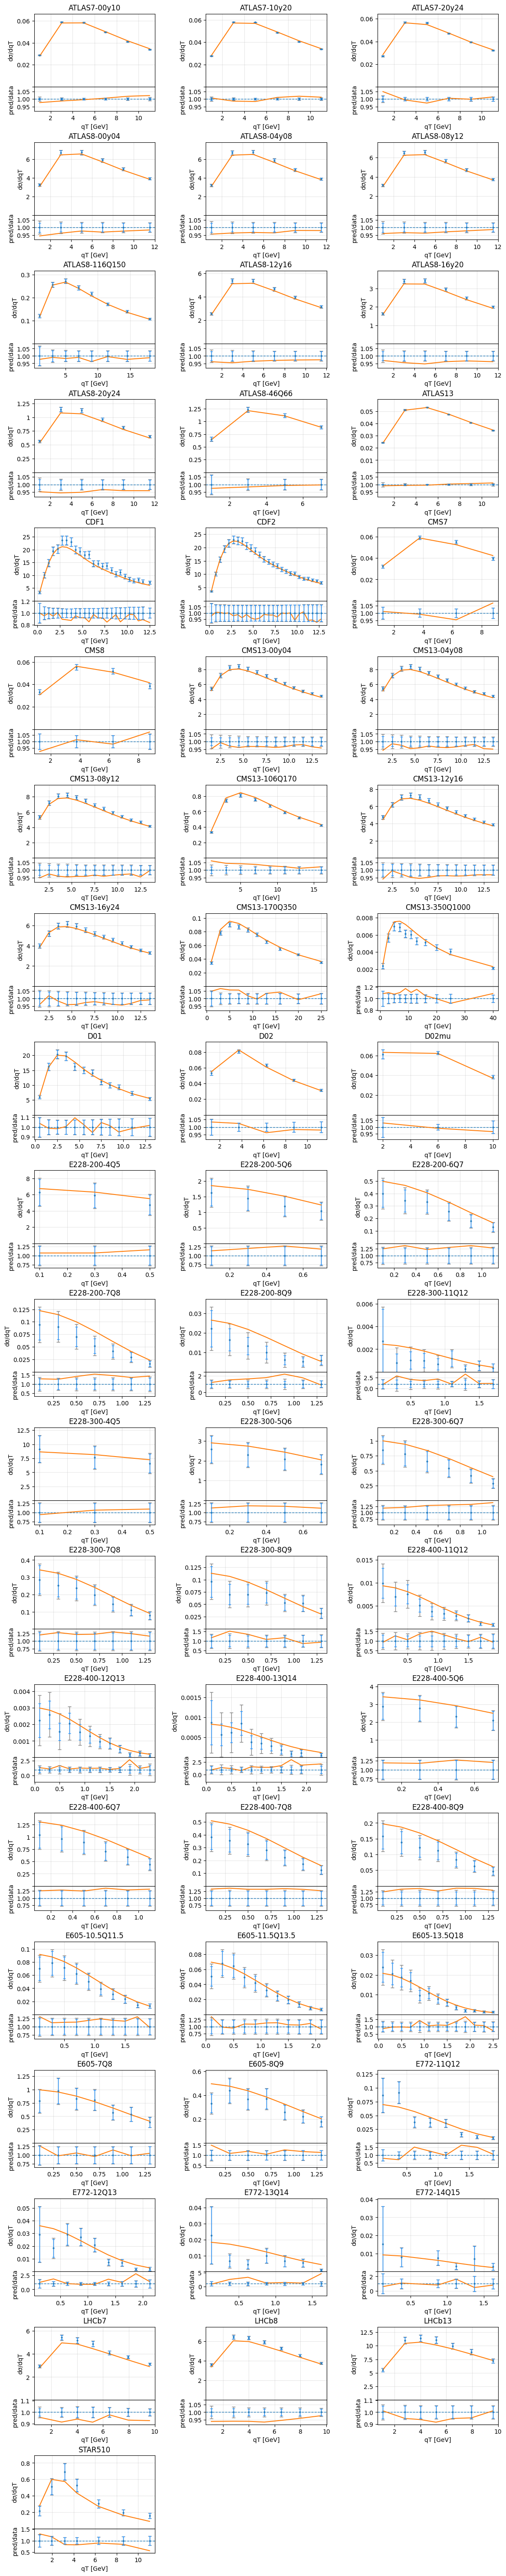

In [19]:
# settings

data_color = "dodgerblue"
total_error_color = "gray"
prediction_color = 'tab:orange'

prediction_width = 1.5
fmt = "o"
fmt_size = 2

import math
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from pathlib import Path

# Order to plot (or: sorted(file_names))
files_in_order = list(plots_list.keys())
max_cols_per_row = 3

n_files = len(files_in_order)
if n_files == 0:
    raise ValueError("No files to plot.")

ncols = min(max_cols_per_row, n_files)
nrow_pairs = math.ceil(n_files / ncols)

# Figure & outer grid (spacing BETWEEN files)
fig = plt.figure(figsize=(4.6 * ncols, 3.8 * nrow_pairs))
outer = fig.add_gridspec(nrows=nrow_pairs, ncols=ncols, wspace=0.42, hspace=0.32)

# Hide only the "0" tick label on the spectrum axis
hide_zero_label = FuncFormatter(lambda y, pos: "" if np.isclose(y, 0.0) else f"{y:g}")

def set_spectrum_ylim(ax, y_data, y_err, y_pred, pad_frac=0.12):
    """
    Bottom fixed at 0. Top = max(data+err, prediction) * (1 + pad_frac).
    Purely percentage-based (no fixed absolute padding).
    """
    y_data = np.asarray(y_data, float)
    y_err  = np.asarray(y_err,  float)
    y_pred = np.asarray(y_pred, float)

    data_up = y_data + np.nan_to_num(y_err, nan=0.0)
    candidates = np.concatenate([
        data_up[np.isfinite(data_up)],
        y_pred[np.isfinite(y_pred)]
    ])
    if candidates.size == 0:
        ax.set_ylim(0.0, 1.0)
        return

    ymax = float(np.max(candidates))
    if not np.isfinite(ymax) or ymax <= 0:
        ax.set_ylim(0.0, 1.0)
        return

    ax.set_ylim(0.0, np.nextafter(ymax * (1.0 + pad_frac), np.inf))

def set_ratio_ylim_symmetric_around_one(ax, ratio_vals, ratio_errs,
                                        margin_frac=0.22, min_half_frac=0.08):
    """
    Symmetric about y=1.0, covering ratio points AND 1±err, with percentage-based extra margin.
      - margin_frac: extra headroom as a fraction of the required half-span
      - min_half_frac: minimum half-span as a fraction of 1.0
    """
    r = np.asarray(ratio_vals, float)
    e = np.asarray(ratio_errs, float)
    r_finite = r[np.isfinite(r)]
    e_finite = e[np.isfinite(e)]

    if r_finite.size == 0 and e_finite.size == 0:
        half = max(min_half_frac, 0.10)
        ax.set_ylim(1.0 - half, 1.0 + half)
        return

    lower_from_points = np.min(r_finite) if r_finite.size else np.inf
    upper_from_points = np.max(r_finite) if r_finite.size else -np.inf

    if e_finite.size:
        max_err = float(np.nanmax(e_finite))
        lower_from_errors = 1.0 - max_err
        upper_from_errors = 1.0 + max_err
    else:
        lower_from_errors = np.inf
        upper_from_errors = -np.inf

    lower = min(lower_from_points, lower_from_errors)
    upper = max(upper_from_points, upper_from_errors)

    half_needed = max(1.0 - lower, upper - 1.0, 0.0)
    half = max(half_needed * (1.0 + margin_frac), min_half_frac)
    ax.set_ylim(1.0 - half, 1.0 + half)

for idx, fname in enumerate(files_in_order):
    r = idx // ncols
    c = idx % ncols

    # Inner grid per file: top+bottom, zero vertical gap; share x within the pair
    inner = outer[r, c].subgridspec(nrows=2, ncols=1, height_ratios=[3, 1], hspace=0.0)
    ax_top = fig.add_subplot(inner[0, 0])
    ax_bot = fig.add_subplot(inner[1, 0], sharex=ax_top)

    plot_df = plots_list[fname]
    qT              = plot_df["qT_array"].to_numpy()
    data_vals       = plot_df["data_array"].to_numpy()
    pred_vals       = np.asarray(plot_df["prediction_array"], float)
    data_err        = plot_df["error_data_array"].to_numpy()
    total_err       = plot_df["error_total_array"].to_numpy()
    ratio_vals      = plot_df["ratio_array"].to_numpy()
    ratio_err_data  = plot_df["error_data_ratio_array"].to_numpy()
    ratio_err_total = plot_df["error_total_ratio_array"].to_numpy()

    y_err_max = np.maximum(data_err, total_err)

    # --- Top: data ± errors vs prediction ---
    ax_top.errorbar(qT, data_vals, yerr=total_err, fmt='none', ecolor=total_error_color, elinewidth=1, capsize=3, label="total err")
    ax_top.errorbar(qT, data_vals, yerr=data_err, fmt=fmt, mfc='none',ms=fmt_size, elinewidth=1, capsize=2, label="data err", ecolor=data_color)
    ax_top.plot(qT, pred_vals, linewidth=prediction_width, label="prediction", color=prediction_color)
    ax_top.set_title(Path(fname).stem)
    ax_top.set_ylabel("dσ/dqT")
    ax_top.grid(True, alpha=0.3)
    set_spectrum_ylim(ax_top, data_vals, y_err_max, pred_vals)     # starts at 0, % headroom
    ax_top.yaxis.set_major_formatter(hide_zero_label)             # hide "0" label
    ax_top.tick_params(labelbottom=False)                         # no x labels on top panel
    # show the separator line between panels (keep both spines visible)
    ax_top.spines['bottom'].set_visible(True)
    #if idx == 0:
    #    ax_top.legend(frameon=False)

    ratio_err_max = np.maximum(ratio_err_data, ratio_err_total)

    # --- Bottom: ratio, symmetric about 1.0 with % margin ---
    ax_bot.axhline(1.0, linestyle="--", linewidth=1)
    ax_bot.plot(qT, ratio_vals, linewidth=prediction_width, color=prediction_color)
    ax_bot.errorbar(qT, np.ones_like(qT), yerr=ratio_err_total, fmt='none', ecolor=total_error_color, elinewidth=1, capsize=3)
    ax_bot.errorbar(qT, np.ones_like(qT), yerr=ratio_err_data, fmt=fmt, mfc='none', ecolor=data_color, elinewidth=1, capsize=2, ms=fmt_size)
    ax_bot.set_xlabel("qT [GeV]")
    ax_bot.set_ylabel("pred/data")
    ax_bot.grid(True, alpha=0.3)
    set_ratio_ylim_symmetric_around_one(ax_bot, ratio_vals, ratio_err_max,
                                        margin_frac=0.22, min_half_frac=0.08)
    ax_bot.spines['top'].set_visible(True)  # separator remains visible

plt.tight_layout()
plt.show()


Test accuracy

In [20]:
test_accuracy = False
if test_accuracy:
    import pickle
    from pathlib import Path
    import numpy as np
    import pandas as pd

    with open(f"../Predict/{Main.table_name}/{Main.i_member}.pkl", "rb") as f:
        predictions_saved = prediction_reformat(pickle.load(f))

    display(predictions_saved)

    common = set(df_predictions) & set(predictions_saved)

    rows = []
    for k in common:
        pred = np.asarray(df_predictions[k], float)
        ref  = np.asarray(predictions_saved[k], float)

        rel = np.where(ref == 0, np.inf, (pred - ref) / ref)   # fraction
        metric = float(np.nanmax(np.abs(rel)))                # fraction

        rows.append((Path(k).name, metric, rel))

    df_rel = pd.DataFrame(rows, columns=["path", "rel_err_max", "rel_err"])
    df_rel = df_rel.sort_values("rel_err_max", ascending=False)

    # display options
    pd.set_option("display.width", None)
    pd.set_option("display.max_rows", None)
    pd.set_option("display.max_colwidth", None)

    # show rel_err array in percent
    df_rel["rel_err"] = df_rel["rel_err"].map(
        lambda a: np.array2string(100 * a, precision=1, suppress_small=False) + " %"
    )

    display(
        df_rel.style
            .hide(axis="index")
            .format({"rel_err_max": "{:.1%}"})  # 0.012 -> 1.200%
    )